# 18 — Evaluate motion information from the saved GAVD grid

This notebook loads the **same five-fold, five-seed grid trained in
Notebook 17**, including real train/test source membership. It never
starts encoder training. In a fresh kernel, it reconstructs expected
data/model identities, locates every saved job, and reuses or recomputes
its frozen readouts. A missing job produces an explicit status table;
a partial grid cannot become a full-grid result.

The central question from [TUTORIAL.md](docs/TUTORIAL.md) is whether
training learns useful movement information that simple averaging hides.
We compare temporal summaries against the same summaries of initial
features, then inspect predictor correspondence separately. This makes
favorable and unfavorable results equally interpretable.

### What to look for in the reviewed results — 2026-09-08

The complete real-data grid supports a specific conclusion: temporal
summaries improve the initial encoder's readout more than the trained
encoders' readout. Initial mean-motion features reach mean R² **0.223**;
trained teachers reach **0.101–0.114**, with every teacher arm below its
matched initial control in all five seeds. Mask-versus-uniform intervals
include zero. Section 9 explains these results, the positive predictor
diagnostic, and a concrete sequence of follow-up analyses. It also states
what the evidence cannot distinguish. Existing outputs remain unchanged.

In [ ]:
from pathlib import Path
from dataclasses import asdict, replace
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

def locate_suite():
    for parent in (Path.cwd(), *Path.cwd().parents):
        for candidate in (parent, parent / "neurips-laterality"):
            if (candidate / "laterality_extensions/motion_structured_masks.py").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Run from the research project directory.")

SUITE_ROOT = locate_suite()
if str(SUITE_ROOT) not in sys.path:
    sys.path.insert(0, str(SUITE_ROOT))
from laterality_extensions.motion_structured_masks import (
    StudyArm, mamp_logits, sample_study_mask, study_arms,
    paired_study_masks, context_cue_audit,
)
from laterality_extensions.comparative_masks import motion_scores
from notebook_progress import (
    NotebookTaskProgress, run_notebook_task, study_inputs_with_progress,
    audit_training_masks_with_progress, grid_status_with_progress,
    run_gavd_grid_with_progress, collect_gavd_grid_with_progress,
    evaluate_retained_motion_with_progress,
)
set_matplotlib_formats("svg", "png")
pd.set_option("display.precision", 3)

## 1. Load the real GAVD cohort and declare the full split/seed grid

Run cells in order in a Python kernel with the project's dependencies.
Long tasks use the shared `notebook_progress.py` wrapper: one updating
display shows the current stage, fold/seed, elapsed time and estimated
remaining time. Mask batches and optimizer updates appear within their
active stage. ETA adjusts as stages finish; their costs differ. Cached,
disabled, missing-input and failed tasks receive explicit status labels.
`DATA_MODE="gavd"` is the default. The helper below follows the same
preparation and source splitting functions as notebooks 01 and 02:

1. Verify an existing paper-profile cohort and split manifest by their
   content hashes. If absent, read the local GAVD pose archives and
   official annotations, apply the existing QC and target rules, and
   create those two artifacts. The first run takes longer.
2. The protocol fixes 642 pose archives and 666 annotations. If the local
   cache contains later additions, recover the original extraction
   generations only when their inventory **exactly** matches the locked
   count and SHA-256. Store verified copies under the paper artifact
   root. The original cache stays intact. A mismatch stops with an
   actionable error; it cannot silently switch to generated data.
3. The reference QC result is 625 clips from 93 source videos. Inputs have
   shape `[clips, 64, 33, 3]`; four prepared steps form each of 16 tokens
   per landmark. Naturally missing observations remain marked invalid.
   The target is a coordinate-derived bilateral movement contrast, not
   the dataset's condition annotation.
4. Reuse the five video-disjoint outer folds. Seeds 42--46 change
   initialization, source draws, augmentations and masks; they repeat
   the **same** train/test partitions. A video is held out exactly once
   per seed. There are 25 fold/seed combinations, not 25 independent
   datasets. Video separation does not establish subject separation.

The printed census makes train and test membership visible. Source IDs
and sequence IDs are retained in `inputs["memberships"]`. The reference
train/test clip counts are 436/189, 443/182, 553/72, 548/77 and 520/105.
Unequal clip counts are expected because entire videos stay together.

A small generated-data path remains available only through the explicit
`LATERALITY_MOTION_DATA_MODE=synthetic` software-check setting. It prints
its reduced scope and uses a separate artifact directory. It provides
no GAVD results. See [the run guide](docs/MOTION_GAVD_WORKFLOW.md) for
paths, environment settings, recovery and a notebook-by-notebook walkthrough.

In [2]:
from laterality_extensions.motion_gavd import gavd_plan, readout_contrasts
DATA_MODE = os.getenv("LATERALITY_MOTION_DATA_MODE", "gavd")
FOLDS = (0, 1, 2, 3, 4)
SEEDS = (42, 43, 44, 45, 46)
EXPERIMENTS = tuple(os.getenv("LATERALITY_MOTION_EXPERIMENTS", "motion,regions").split(","))
CREATE_MISSING_INPUTS = True
DEVICE = os.getenv("LATERALITY_DEVICE", "auto")
# Keep the numerical mode identical in Notebooks 17 and 18.
PRECISION = os.getenv("LATERALITY_MOTION_PRECISION", "fp32")  # or "bf16" on native CUDA BF16 hardware
RESUME_INTERVAL = int(os.getenv("LATERALITY_MOTION_RESUME_INTERVAL", "100"))
# Same explicit training switch as Notebook 12; also accept the study-specific alias.
RUN_TRAINING = os.getenv("LATERALITY_MOTION_RUN_REAL",
                        os.getenv("LATERALITY_RESEARCH_RUN_REAL", "0")) == "1"
if DATA_MODE == "synthetic":
    FOLDS, SEEDS = (0,), (42,)
    print("EXPLICIT SYNTHETIC SOFTWARE CHECK: one fold/seed, one update, no GAVD evidence")
OUTPUT_ROOT = Path(os.getenv("LATERALITY_MOTION_OUTPUT_ROOT", str(SUITE_ROOT / "artifacts" /
    ("motion_structured" if DATA_MODE == "gavd" else "motion_structured_synthetic"))))
print(f"Mode={DATA_MODE}; folds={FOLDS}; seeds={SEEDS}; device={DEVICE}")
print(f"Training enabled={RUN_TRAINING}; outputs={OUTPUT_ROOT}")

Mode=gavd; folds=(0, 1, 2, 3, 4); seeds=(42, 43, 44, 45, 46); device=cuda
Training enabled=True; outputs=C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-laterality\artifacts\motion_structured


In [3]:
input_progress = NotebookTaskProgress("Dataset preparation and source splits", "stage")
inputs = study_inputs_with_progress(mode=DATA_MODE, folds=FOLDS, seeds=SEEDS,
    create_missing=CREATE_MISSING_INPUTS, progress=input_progress)
display(inputs["census"])
assert inputs["census"].source_overlap.eq(0).all()
display(inputs["memberships"].head(8))
if DATA_MODE == "gavd":
    cohort = inputs["cohort"]
    display(cohort.table.groupby("condition").agg(
        accepted_clips=("sequence_id", "size"), source_videos=("video_id", "nunique")))
    display(pd.Series({key: cohort.attrition[key] for key in
        ("input_sequences", "accepted_sequences", "accepted_sources", "excluded_sequences")}))
    print("Cohort:", cohort.cohort_digest)
    print("Split:", inputs["splits"]["split_digest"])
    print("Artifacts:", inputs["context"].artifact_root)

,fold,seed,train_clips,test_clips,train_sources,test_sources,source_overlap,synthetic
0,0,42,436,189,74,19,0,False
1,0,43,436,189,74,19,0,False
2,0,44,436,189,74,19,0,False
3,0,45,436,189,74,19,0,False
4,0,46,436,189,74,19,0,False
5,1,42,443,182,74,19,0,False
6,1,43,443,182,74,19,0,False
7,1,44,443,182,74,19,0,False
8,1,45,443,182,74,19,0,False
9,1,46,443,182,74,19,0,False


,sequence_id,source_id,fold,seed,role
0,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,train
1,cljo2y1f7001e3n6lt1wgacw6,3KnFt8bH3tE,0,42,train
2,cljo2yqzp001i3n6lg75p7wtq,3KnFt8bH3tE,0,42,train
3,cljo2zn41001m3n6lhbvww48i,3KnFt8bH3tE,0,42,train
4,cljo30lnz001q3n6lopfty7q5,3KnFt8bH3tE,0,42,train
5,cljo32213001u3n6lel97up5f,3KnFt8bH3tE,0,42,train
6,cljo32ik2001y3n6lmmnu0sgo,3KnFt8bH3tE,0,42,train
7,cljo32xnz00223n6lvxzyif3y,3KnFt8bH3tE,0,42,train


,accepted_clips,source_videos
condition,,
cerebralpalsy,58,9
myopathic,183,28
normal,270,29
parkinsons,39,9
stroke,75,18


input_sequences       642
accepted_sequences    625
accepted_sources       93
excluded_sequences     17
dtype: int64

Cohort: bc23447824d2bc2bbe62dfdc7df5da8db7d1e73291d1675f2556597eeeefe2e3
Split: 0dd230e67d5eb583013ef6e4e295713d30e30799eea160adc8cb51b4db58eb1b
Artifacts: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-laterality\artifacts\paper\protocol_6f7baefbda07


## 2. Reconstruct the exact training grid before loading results

Keep `DATA_MODE`, `FOLDS`, `SEEDS`, `EXPERIMENTS`, `DEVICE` and
`OUTPUT_ROOT` identical to Notebook 17. The `RUN_TRAINING` variable has
no effect in this notebook. Model initialization settings and the resolved
backend are part of compatibility; changing them identifies a different
job. A saved manifest is not its own proof of compatibility.

The primary declaration expects 50 paired jobs containing 125 encoders.
The census verifies test coverage independently of the prediction files.
With all five folds, every accepted sequence must appear in a test set
exactly once per seed. Changing the scope to a subset creates a pilot.

In [4]:
plan = gavd_plan(inputs, experiments=EXPERIMENTS, device=DEVICE, output_dir=OUTPUT_ROOT,
                 precision=PRECISION, resume_interval=RESUME_INTERVAL)
display(pd.Series({key: plan[key] for key in
    ("scope", "training_runs", "optimizer_updates", "recipe_source", "output_dir")}))
display(pd.Series(plan["settings"], name="Declared training settings"))
display(pd.Series(plan["execution"], name="Execution and recovery settings"))
display(plan["workload"].groupby(["experiment", "fold", "seed"], sort=False).agg(
    encoders=("condition", "size"), optimizer_updates=("updates", "sum")))
display(pd.DataFrame([{"experiment": e, **arm} for e, arms in plan["arms"].items()
                      for arm in arms.values()]))

scope                                      full development comparison
training_runs                                                      125
optimizer_updates                                               150000
recipe_source        C:\Users\alexm\dev\alexpose\experiments\sjepa\...
output_dir           C:\Users\alexm\dev\alexpose\experiments\sjepa\...
dtype: object

seed                          7
fold                          0
steps                      1200
batch_size                   20
embed_dim                    96
encoder_depth                 4
predictor_depth               2
heads                         4
segment_length                4
learning_rate             0.001
weight_decay               0.05
mask_fraction               0.5
mask_policy                gait
random_subset_seed           31
ridge_alpha                 1.0
reflection_probability      0.0
symmetry_weight             0.0
vicreg_weight              0.05
ema_momentum              0.999
device                     cuda
confirm_real_run          False
Name: Declared training settings, dtype: object

precision          bf16
resume_interval     100
Name: Execution and recovery settings, dtype: object

encoders  optimizer_updates
experiment fold seed                             
motion     0    42           3               3600
                43           3               3600
                44           3               3600
                45           3               3600
                46           3               3600
           1    42           3               3600
                43           3               3600
                44           3               3600
                45           3               3600
                46           3               3600
           2    42           3               3600
                43           3               3600
                44           3               3600
                45           3               3600
                46           3               3600
           3    42           3               3600
                43           3               3600
                44           3               3600
                45           3               3600
                46           3               3600
           4    42           3               3600
                43           3               3600
                44           3               3600
                45           3               3600
                46           3               3600
regions    0    42           2               2400
                43           2               2400
                44           2               2400
                45           2               2400
                46           2               2400
           1    42           2               2400
                43           2               2400
                44           2               2400
                45           2               2400
                46           2               2400
           2    42           2               2400
                43           2               2400
                44           2               2400
                45           2               2400
                46           2               2400
           3    42           2               2400
                43           2               2400
                44           2               2400
                45           2               2400
                46           2               2400
           4    42           2               2400
                43           2               2400
                44           2               2400
                45           2               2400
                46           2               2400

,experiment,name,temperature,motion_weight,clip_quantile,trajectories,region_size,interval_blocks
0,motion,uniform,0.8,0.75,0.95,3,6,2
1,motion,mamp_motion,0.8,0.75,0.95,3,6,2
2,motion,robust_motion,0.8,0.75,0.95,3,6,2
3,regions,uniform,0.8,0.75,0.95,3,6,2
4,regions,connected_region,0.8,0.75,0.95,3,6,8


,experiment,fold,seed,encoders,training_status,training_directory
0,motion,0,42,3,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
1,regions,0,42,2,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
2,motion,0,43,3,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
3,regions,0,43,2,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
4,motion,0,44,3,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
5,regions,0,44,2,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
6,motion,0,45,3,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
7,regions,0,45,2,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
8,motion,0,46,3,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...
9,regions,0,46,2,complete; content hashes verified,C:\Users\alexm\dev\alexpose\experiments\sjepa\...


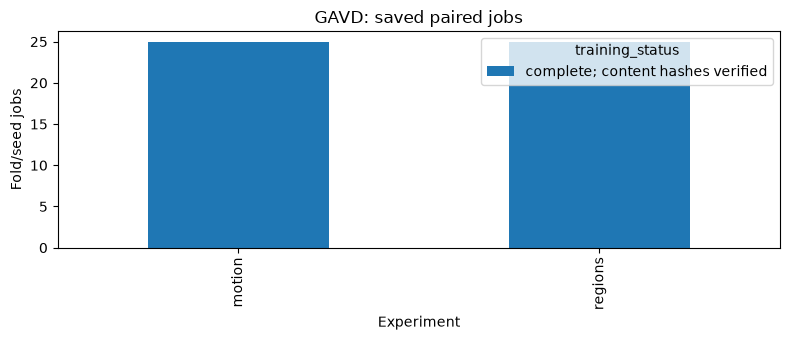

In [5]:
checkpoint_progress = NotebookTaskProgress("Saved GAVD checkpoint inspection", "stage")
status = grid_status_with_progress(plan, inputs, progress=checkpoint_progress)
display(status)
availability = status.groupby(["experiment", "training_status"]).size().unstack(fill_value=0)
ax = availability.plot.bar(stacked=True, figsize=(8, 3.5), title=f"{DATA_MODE.upper()}: saved paired jobs")
ax.set(xlabel="Experiment", ylabel="Fold/seed jobs")
ax.figure.tight_layout(); display(ax.figure); plt.close(ax.figure)

## 3. Separate representation learning from readout design

| Representation | What is frozen? | Inference it supports |
|---|---|---|
| `pretrained_online__mean` / `__mean_motion` | Trained online encoder | Content available without the JEPA predictor |
| `pretrained_teacher__mean` / `__mean_motion` | Final EMA teacher | Teacher representation quality |
| `initial_online__mean` / `__mean_motion` | Same job's initial encoder | Architecture and readout control |
| `direct_pose` | Prepared coordinates | Information already accessible from pose summaries |
| `training_mean` | Training-source target mean | No-feature prediction baseline |

`mean` retains the existing five bilateral sums and differences of
average features. `mean_motion` also includes temporal standard
deviation, mean absolute consecutive feature changes and valid-support
fractions. Only common bilateral support and adjacent valid transitions
contribute. The summaries describe prepared tokens; they cannot restore
physical timing lost during input resizing.

The ridge grid is 0.01, 0.1, 1, 10, 100, 1,000 and 10,000. Preprocessing
and alpha selection use outer-training sources only. This extension uses
the comparative readout helper's **three source-separated inner groups**;
these are not the registered protocol's four inner model-selection
folds. Pretraining sees all outer-training sources, so this inner step
selects the readout only. Tuning an entire encoder recipe would require
excluding inner-validation sources from candidate pretraining too.

Both summaries are declared outputs. Outer-test scores cannot choose a
summary, checkpoint or alpha. A boundary alpha is reported for inspection;
a wide grid alone does not guarantee adequate regularization.

In [6]:
evaluation_progress = NotebookTaskProgress("Saved-grid readouts and source-level reporting", "stage")
results = collect_gavd_grid_with_progress(plan, inputs, progress=evaluation_progress)
print(results["status"])
COMPLETE = results["status"] == "Complete"
if COMPLETE:
    print("Verified grid report:", results["directory"])
    display(results["jobs"])
    display(results["per_seed"][["experiment", "condition", "representation", "seed",
        "r2", "mae", "evaluated_clips", "evaluated_sources"]])
else:
    display(results["jobs"].query("training_status == 'missing'"))
    print("Complete these jobs in Notebook 17, then rerun this cell. No substitute model was trained.")

Complete
Verified grid report: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-laterality\artifacts\motion_structured\grids\292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57


,experiment,fold,seed,training_directory,evaluation_directory,training_digest,evaluation_digest
0,motion,0,42,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,97112fcaa106607f892ae071506e14856ff53869d5175f...,5263b0fa37dac9c22d61cd8a7b4d6f25f4244274b75988...
1,regions,0,42,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,9c439fd6f1f1ef690ebf99de5c3b0ca0c9f3a01bdfdf34...,d142b103b28204bc4514026a60ef79ab31d3dc8640e415...
2,motion,0,43,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,20e38f5ed338b17f2a255575d230ceea28b4eccfaca4ee...,e0db15be5e64664fef80a0e21444d99868b85c03c890d7...
3,regions,0,43,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,ba905987c3fb80f5c8a71fccfcdb5d4c78a815ef2da04a...,1830769efabb43a2b36720f9cebdcd8c531c27240d9cb8...
4,motion,0,44,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,63e893bcbd8487bbcbaba187a882df878e64685b95c788...,082900581d90b8efc86b4594b94f9535bd3588ab7d777a...
5,regions,0,44,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,dd1a73301ab248827a01739b2953d57ba2681f57280afb...,734958bc8fb885946d4e29e7ef252134512f69aaf68596...
6,motion,0,45,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,cf6b0fb1fcf436048ee8d756528c3b946cfd0d5bf34083...,4e8e0acf5a04176f397a08069187567740aab9d2a7121c...
7,regions,0,45,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,4fb27504d262da513cab7621872fe590ba5bd8f77b9b9b...,8f4dc23a40093056538617b23947a8e9682fbb883b8306...
8,motion,0,46,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,2c58c592270392611ff7eeaa046d80287af885d75fcf13...,672b2b38efcf1d464ff1fe5e64b0cac5f286ae769ebebb...
9,regions,0,46,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,C:\Users\alexm\dev\alexpose\experiments\sjepa\...,069f4e938f22218acd55d461f389ff32ac67fcb9f347d2...,e34164c17b39bc9272610dd9732c133a429e5b38e4ab7f...


,experiment,condition,representation,seed,r2,mae,evaluated_clips,evaluated_sources
0,motion,mamp_motion,direct_pose,42,0.035,0.045,625,93
1,motion,mamp_motion,direct_pose,43,0.035,0.045,625,93
2,motion,mamp_motion,direct_pose,44,0.035,0.045,625,93
3,motion,mamp_motion,direct_pose,45,0.035,0.045,625,93
4,motion,mamp_motion,direct_pose,46,0.035,0.045,625,93
...,...,...,...,...,...,...,...,...
195,regions,uniform,training_mean,42,-0.011,0.046,625,93
196,regions,uniform,training_mean,43,-0.011,0.046,625,93
197,regions,uniform,training_mean,44,-0.011,0.046,625,93
198,regions,uniform,training_mean,45,-0.011,0.046,625,93


## 4. Pool predictions correctly and inspect paired differences

R² and MAE are calculated after pooling all declared outer-test folds
for each seed, with equal total weight per source video. With the full
GAVD grid, each arm/summary/seed has 625 predictions from 93 videos.
Fold-specific R² has a different denominator and must not be averaged.
A negative pooled R² means worse squared error than the pooled weighted
test-target mean; the deployable training-mean control is shown separately.

For the tables below, positive `delta_r2` and negative `delta_mae` favor
the first representation in the contrast. Compare trained against initial
within the **same** summary before attributing gains to learning.
The saved `paired_intervals` additionally compares each mask arm with its
own uniform control using teacher mean-motion features and 2,000 paired
source-video bootstrap resamples. Whole videos, clips and paired seed
predictions stay together. Those intervals condition on fitted models;
they do not measure full retraining uncertainty. Seed variation is separate.

In [7]:
if COMPLETE:
    display(results["summary"])
    contrasts = readout_contrasts(results["per_seed"])
    display(contrasts)
    display(contrasts.groupby(["experiment", "condition", "contrast"], sort=False).agg(
        mean_delta_r2=("delta_r2", "mean"), seed_sd_delta_r2=("delta_r2", "std"),
        mean_delta_mae=("delta_mae", "mean")))
    display(results["paired_intervals"])
    selected = results["selection"].query("selected")
    display(selected[["experiment", "condition", "representation", "fold", "seed",
                      "selected_alpha", "at_grid_boundary"]])
    display(results["diagnostics"][["experiment", "condition", "representation", "fold", "seed",
                                    "effective_rank", "near_constant"]])
else:
    print("No complete declared grid: performance and learned-over-initial inference remain pending.")

,condition,representation,observation,mean_r2,seed_sd_r2,mean_mae,seed_sd_mae,evaluated_seeds,evaluated_clips_min,evaluated_clips_max,evaluated_sources_min,unavailable_clips_max,scope,experiment
0,mamp_motion,direct_pose,unaltered,0.035,0.000,0.045,0.000e+00,5,625,625,93,0,complete declared comparison,motion
1,mamp_motion,initial_online__mean,unaltered,0.071,0.019,0.044,4.616e-04,5,625,625,93,0,complete declared comparison,motion
2,mamp_motion,initial_online__mean_motion,unaltered,0.223,0.027,0.042,8.028e-04,5,625,625,93,0,complete declared comparison,motion
3,mamp_motion,pretrained_online__mean,unaltered,0.059,0.004,0.044,1.203e-04,5,625,625,93,0,complete declared comparison,motion
4,mamp_motion,pretrained_online__mean_motion,unaltered,0.081,0.010,0.044,3.661e-04,5,625,625,93,0,complete declared comparison,motion
5,mamp_motion,pretrained_teacher__mean,unaltered,0.067,0.006,0.044,3.253e-04,5,625,625,93,0,complete declared comparison,motion
6,mamp_motion,pretrained_teacher__mean_motion,unaltered,0.113,0.031,0.044,5.921e-04,5,625,625,93,0,complete declared comparison,motion
7,mamp_motion,training_mean,unaltered,-0.011,0.000,0.046,0.000e+00,5,625,625,93,0,complete declared comparison,motion
8,robust_motion,direct_pose,unaltered,0.035,0.000,0.045,0.000e+00,5,625,625,93,0,complete declared comparison,motion
9,robust_motion,initial_online__mean,unaltered,0.071,0.019,0.044,4.616e-04,5,625,625,93,0,complete declared comparison,motion


,experiment,condition,seed,contrast,delta_r2,delta_mae
0,motion,mamp_motion,42,"trained over initial, mean",-0.003,-1.463e-04
1,motion,mamp_motion,42,"trained over initial, motion",-0.135,2.820e-03
2,motion,mamp_motion,42,"motion over mean, trained",0.050,-6.528e-04
3,motion,mamp_motion,42,"motion over mean, initial",0.182,-3.619e-03
4,motion,mamp_motion,43,"trained over initial, mean",-0.017,4.330e-04
...,...,...,...,...,...,...
95,regions,uniform,45,"motion over mean, initial",0.148,-2.460e-03
96,regions,uniform,46,"trained over initial, mean",-0.020,3.294e-04
97,regions,uniform,46,"trained over initial, motion",-0.102,2.494e-03
98,regions,uniform,46,"motion over mean, trained",0.027,7.414e-04


mean_delta_r2  \
experiment condition        contrast                                      
motion     mamp_motion      trained over initial, mean       -3.711e-03   
                            trained over initial, motion     -1.097e-01   
                            motion over mean, trained         4.577e-02   
                            motion over mean, initial         1.517e-01   
           robust_motion    trained over initial, mean       -3.433e-03   
                            trained over initial, motion     -1.083e-01   
                            motion over mean, trained         4.681e-02   
                            motion over mean, initial         1.517e-01   
           uniform          trained over initial, mean       -9.902e-04   
                            trained over initial, motion     -1.088e-01   
                            motion over mean, trained         4.389e-02   
                            motion over mean, initial         1.517e-01   
regions    connected_region trained over initial, mean        2.928e-03   
                            trained over initial, motion     -1.218e-01   
                            motion over mean, trained         2.702e-02   
                            motion over mean, initial         1.517e-01   
           uniform          trained over initial, mean       -1.196e-03   
                            trained over initial, motion     -1.131e-01   
                            motion over mean, trained         3.981e-02   
                            motion over mean, initial         1.517e-01   

                                                          seed_sd_delta_r2  \
experiment condition        contrast                                         
motion     mamp_motion      trained over initial, mean               0.021   
                            trained over initial, motion             0.020   
                            motion over mean, trained                0.029   
                            motion over mean, initial                0.027   
           robust_motion    trained over initial, mean               0.015   
                            trained over initial, motion             0.032   
                            motion over mean, trained                0.017   
                            motion over mean, initial                0.027   
           uniform          trained over initial, mean               0.018   
                            trained over initial, motion             0.033   
                            motion over mean, trained                0.010   
                            motion over mean, initial                0.027   
regions    connected_region trained over initial, mean               0.017   
                            trained over initial, motion             0.033   
                            motion over mean, trained                0.011   
                            motion over mean, initial                0.027   
           uniform          trained over initial, mean               0.015   
                            trained over initial, motion             0.020   
                            motion over mean, trained                0.009   
                            motion over mean, initial                0.027   

                                                          mean_delta_mae  
experiment condition        contrast                                      
motion     mamp_motion      trained over initial, mean         5.955e-05  
                            trained over initial, motion       2.205e-03  
                            motion over mean, trained         -6.526e-04  
                            motion over mean, initial         -2.798e-03  
           robust_motion    trained over initial, mean         6.033e-05  
                            trained over initial, motion       2.049e-03  
                            motion over mean, trained         -8.094e-04  
               

,experiment,difference,lower_95,upper_95,metric,subtraction,sources,clips_per_seed,seeds,requested_resamples,finite_resamples,uncertainty_scope
0,motion,-8.343e-04,-0.020,0.015,r2,mamp_motion minus uniform,93,625,5,2000,2000,source resampling conditional on fitted models...
1,motion,4.848e-04,-0.015,0.015,r2,robust_motion minus uniform,93,625,5,2000,2000,source resampling conditional on fitted models...
2,regions,-8.669e-03,-0.033,0.018,r2,connected_region minus uniform,93,625,5,2000,2000,source resampling conditional on fitted models...


,experiment,condition,representation,fold,seed,selected_alpha,at_grid_boundary
6,motion,uniform,pretrained_online__mean,0,42,10000.0,True
12,motion,uniform,pretrained_online__mean_motion,0,42,1000.0,False
20,motion,uniform,pretrained_teacher__mean,0,42,10000.0,True
26,motion,uniform,pretrained_teacher__mean_motion,0,42,1000.0,False
33,motion,uniform,initial_online__mean,0,42,1000.0,False
...,...,...,...,...,...,...,...
6096,regions,connected_region,pretrained_teacher__mean,4,46,10000.0,True
6103,regions,connected_region,pretrained_teacher__mean_motion,4,46,10000.0,True
6109,regions,connected_region,initial_online__mean,4,46,1000.0,False
6116,regions,connected_region,initial_online__mean_motion,4,46,1000.0,False


,experiment,condition,representation,fold,seed,effective_rank,near_constant
0,motion,uniform,pretrained_online__mean,0,42,15.916,False
1,motion,uniform,pretrained_online__mean_motion,0,42,40.433,False
2,motion,uniform,pretrained_teacher__mean,0,42,10.749,False
3,motion,uniform,pretrained_teacher__mean_motion,0,42,33.448,False
4,motion,uniform,initial_online__mean,0,42,8.891,False
...,...,...,...,...,...,...,...
870,regions,connected_region,pretrained_teacher__mean,4,46,9.335,False
871,regions,connected_region,pretrained_teacher__mean_motion,4,46,30.469,False
872,regions,connected_region,initial_online__mean,4,46,7.986,False
873,regions,connected_region,initial_online__mean_motion,4,46,33.119,False


## 5. Ask whether the predictor preserves clip correspondence

Frozen encoder readout and JEPA prediction answer different questions.
Every saved job also uses the same prespecified evaluation masks (bank
seed 1801), including scattered targets and bilateral leg gaps. The normal
pathway is online encoder → predictor, with full-input teacher targets.
Initial-model controls undergo the same diagnostics.

Compare `mismatched_target_mse` against
`matched_target_mse_on_control_clips`: these use the same subset where a
cross-source mismatch exists. A larger mismatch error supports sensitivity
to clip correspondence. A smaller raw own-teacher MSE across two trained
arms cannot rank semantics, because their teacher spaces and scales differ.
`normalized_error` divides by mean squared teacher-channel value, not
centered variance. Inspect feature variation and effective rank as well.

In [8]:
if COMPLETE:
    predictor = results["predictor_diagnostics"].copy()
    predictor["correspondence_gap"] = (
        predictor.mismatched_target_mse - predictor.matched_target_mse_on_control_clips)
    display(predictor[["experiment", "condition", "fold", "seed", "evaluation_mask",
        "evaluated_clips", "evaluated_sources", "feature_mse", "normalized_error",
        "matched_target_mse_on_control_clips", "mismatched_target_mse", "correspondence_gap"]])
else:
    print("Predictor diagnostics await the same saved GAVD grid; no synthetic scores substituted.")

,experiment,condition,fold,seed,evaluation_mask,evaluated_clips,evaluated_sources,feature_mse,normalized_error,matched_target_mse_on_control_clips,mismatched_target_mse,correspondence_gap
0,motion,uniform,0,42,left_leg_gap,188,19,0.660,0.673,0.660,1.083,0.423
1,motion,uniform,0,42,right_leg_gap,187,19,0.668,0.681,0.668,1.122,0.454
2,motion,uniform,0,42,scattered_gap,188,19,0.635,0.650,0.635,1.005,0.370
3,motion,mamp_motion,0,42,left_leg_gap,188,19,0.679,0.692,0.679,1.118,0.438
4,motion,mamp_motion,0,42,right_leg_gap,187,19,0.704,0.717,0.704,1.144,0.440
...,...,...,...,...,...,...,...,...,...,...,...,...
520,regions,connected_region,4,46,right_leg_gap,105,18,0.681,0.700,0.681,1.118,0.438
521,regions,connected_region,4,46,scattered_gap,105,18,0.710,0.729,0.710,1.168,0.458
522,regions,initial,4,46,left_leg_gap,105,18,1.428,1.428,1.428,1.445,0.017
523,regions,initial,4,46,right_leg_gap,105,18,1.424,1.424,1.424,1.446,0.023


## 6. Turn the evidence into the next experiment

| Observed pattern | Supported interpretation | Next investigation |
|---|---|---|
| Temporal summaries help initial and trained features similarly | Readout design explains much of the gain | Keep the matched initial control; avoid crediting JEPA alone |
| Trained-over-initial gain appears under temporal summaries | Averaging may hide learned movement content | Check seeds, source contrasts and regularization diagnostics |
| A mask beats its uniform control but not initial features | Relative masking improvement without demonstrated learning benefit | Inspect the objective and preparation before broader mixtures |
| Low predictor error accompanies near-constant features | Error reduction may reflect an uninformative target space | Inspect teacher variation and mismatch controls |
| Neither readout nor predictor gives useful contrasts | Current representation/task may miss the endpoint | Revisit timing preparation or a focused objective change |

These are conditional interpretations, not conclusions manufactured from
absent results. Report unfavorable outcomes, boundary penalties and
unstable seeds. GAVD has informed these hypotheses; even a full new grid
remains development evidence for a coordinate-derived endpoint.

Missing raw measurements require the before-preparation tests in Notebook
13. Future prediction requires Notebook 14's past-only inputs and
persistence, velocity, mismatched-future and observed-future controls.
Completion masks do not establish forecasting or clinical validity.

## 7. Optional teaching check: a signal that temporal averaging destroys

This last cell is explicitly generated data, separate from the GAVD grid.
Two sinusoidal limbs have different amplitudes but zero temporal means.
A temporal summary should recover their known amplitude contrast while a
mean cannot. This validates a recoverable construction; it does not prove
that real JEPA tokens encode amplitude in the same way.

,summary,r2,mae,alpha,near_constant,test_sources,test_clips,evidence
0,mean,-0.473,3.081e-01,0.01,True,6,12,"generated amplitude control, not GAVD"
1,mean_motion,1.000,1.733e-05,0.01,False,6,12,"generated amplitude control, not GAVD"


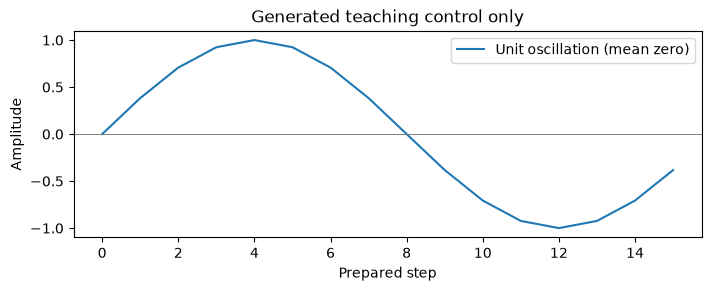

In [9]:
from laterality_extensions.motion_readout import pooling_positive_control
teaching_progress = NotebookTaskProgress("Generated amplitude control", "stage")
teaching_scores, generated = run_notebook_task(pooling_positive_control,
    progress=teaching_progress, label="Fit and evaluate the two generated-data summaries")
display(teaching_scores.assign(evidence="generated amplitude control, not GAVD"))
fig, ax = plt.subplots(figsize=(7, 2.8), constrained_layout=True)
ax.plot(generated["wave"], label="Unit oscillation (mean zero)")
ax.axhline(0, color="gray", linewidth=0.7)
ax.set(title="Generated teaching control only", xlabel="Prepared step", ylabel="Amplitude")
ax.legend(); display(fig); plt.close(fig)

## 8. Optional: reuse a retained Notebook 12 encoder first

If compatible older checkpoints are available, this is the cheaper
readout test recommended in the tutorial. Set
`LATERALITY_RETAINED_COMPARISON` to one Notebook 12 job directory.
The loader checks current data, code and runtime, then saves separate
readouts without changing the original checkpoint. This optional
single-job diagnostic cannot substitute for Notebook 17's full grid.

In [10]:
retained_directory = os.getenv("LATERALITY_RETAINED_COMPARISON", "")
retained_progress = NotebookTaskProgress("Optional Notebook 12 readout reanalysis", "stage")
retained = evaluate_retained_motion_with_progress(retained_directory,
    progress=retained_progress, enabled=bool(retained_directory))
if retained_directory:
    display(retained["selection"].query("selected")[[
        "condition", "representation", "fold", "seed", "selected_alpha", "at_grid_boundary"]])
    print("One retained Notebook 12 job reanalysed without encoder training; separate from the full grid.")
else:
    print("Optional older-checkpoint reanalysis not configured.")

Optional older-checkpoint reanalysis not configured.


## 9. Evaluation of the actual results and a specific next plan

**Evidence snapshot: 2026-09-08.** The analysis below interprets the saved
executions above and the exact [grid manifest](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/manifest.json).
All 50 paired jobs are complete, with CUDA BF16 training and FP32 frozen
evaluation. The review checked artifact file hashes, confirmed 125
complete 1,200-step histories, and independently recomputed the 200 pooled
R²/MAE rows from 125,000 predictions. Every arm/representation/seed covers
625 clips from 93 videos. These are development results for a
coordinate-derived movement contrast, with video rather than verified
person separation.

### Step 1: Compare learning under an identical readout

Values below are from [summary.csv](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/summary.csv). R² is computed
after pooling five outer folds within each seed with equal weight per
video, then averaged over five seeds. “±” denotes **seed standard
deviation**, not a confidence interval. MAE is in the dimensionless target
contrast's units; lower is better.

| Representation / training arm | Mean pooled R² ± seed SD | Mean MAE |
|---|---:|---:|
| Training-source mean | -0.0106 ± 0.0000 | 0.046172 |
| Direct pose summaries | 0.0345 ± 0.0000 | 0.044960 |
| Initial encoder, mean | 0.0708 ± 0.0186 | 0.044344 |
| Initial encoder, mean-motion | **0.2225 ± 0.0268** | **0.041546** |
| Motion-uniform teacher, mean-motion | 0.1137 ± 0.0110 | 0.043658 |
| MAMP teacher, mean-motion | 0.1129 ± 0.0306 | 0.043751 |
| Robust-motion teacher, mean-motion | 0.1142 ± 0.0210 | 0.043595 |
| Region-uniform teacher, mean-motion | 0.1094 ± 0.0088 | 0.044037 |
| Connected-region teacher, mean-motion | 0.1008 ± 0.0092 | 0.043756 |

The initial/direct controls are reused across arms; repeated rows are not
independent replications. The trained online encoders' mean-motion R²
values are also below initial: **0.0805, 0.0809, 0.0740, 0.0657 and
0.0636** in the corresponding five-arm order. The finding therefore is
not explained simply by evaluating the teacher instead of the online model.

Reading [per_seed.csv](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/per_seed.csv) shows teacher-minus-initial
mean-motion R² differences from **-0.1083 to -0.1218** after averaging
seeds. Every arm has a negative difference and higher MAE in **all five
seeds**; MAE increases average **0.00205–0.00249**. This is consistent
unfavorable evidence for this training/readout combination. Five seeds
reuse the same videos, so their agreement is not five independent cohort
replications. The saved mask intervals below are a different comparison.

### Step 2: Interpret the temporal-summary gain correctly

Adding SD, absolute feature increments and support fractions improves the
initial encoder by **+0.1517 R²**, from 0.0708 to 0.2225. The same change
improves trained teachers by only **+0.0270 to +0.0468**. Thus simple
averaging does omit useful predictive features, but restoring those
summary components does not reveal a trained-over-initial advantage.

This experiment changes several readout components together. Temporal SD
does not depend on order, and support fractions describe missingness.
The gain cannot yet be assigned specifically to ordered movement,
amplitude, or missingness. The strong initial control can exploit the
architecture, anatomical pooling and prepared input without pretraining.
It is evidence of accessible predictive structure, not proof of learned
dynamics. Direct pose here is a particular summary-plus-linear-ridge
baseline; its lower score is not an upper bound on information in the
coordinates or on stronger pose baselines.

The generated amplitude control in execution 9 is correctly separate:
mean R² is **-0.473**, while mean-motion R² rounds to **1.000** with MAE
**0.00001733** on 12 clips from six generated sources. Its sine plot shows
why a zero mean loses amplitude. It validates that construction and the
summary calculation; it adds no real GAVD participants or clinical evidence.
Execution 10 confirms that the optional Notebook 12 reanalysis was skipped.

### Step 3: Assess the masking hypothesis with paired uncertainty

The saved [paired intervals](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/paired_intervals.csv) use the final
teacher's mean-motion representation and 2,000 joint source-video
bootstrap resamples, retaining each video's clips and all five seeds.

| Contrast against its own uniform reference | Mean ΔR² | 95% interval |
|---|---:|---:|
| MAMP motion | -0.000834 | [-0.020372, 0.015296] |
| Robust motion | +0.000485 | [-0.015497, 0.015173] |
| Connected regions | -0.008669 | [-0.033290, 0.017666] |

All intervals include zero. No alternative mask demonstrates a benefit
on this readout. The intervals allow modest gains and losses, so “all
masks are equivalent” would also overstate the evidence. They condition
on fitted models and exclude variability from retraining on resampled
cohorts. A paired trained-versus-initial interval would need its own
calculation; these intervals cannot be reused for that claim.

Notebook 16 demonstrates a real reduction in local cues for regions.
That reduction did not produce a demonstrated readout gain. Trajectories
and completion were audited but are absent from this training grid.

### Step 4: Reconcile the predictor result with the readout result

The full [predictor table](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/predictor_diagnostics.csv) contains 525
rows: 375 trained-arm rows and 150 initial-control rows. Each arm contributes
25 fold/seed jobs × three evaluation masks. For every trained row,
`mismatched_target_mse - matched_target_mse_on_control_clips` is positive.
Its descriptive average is **0.433** for MAMP, **0.428** for robust motion,
**0.435** for motion-uniform, **0.345** for regions, and **0.418** for
region-uniform. The initial controls average **-0.003** and are positive
in only 33 of 75 rows per experiment. These averages describe diagnostic
rows; they are not pooled patient outcomes or independent significance tests.

The predictor distinguishes a matching clip from a different source's
target much more consistently after training. That is a useful positive
finding. It could reflect movement, pose, appearance-related geometry,
recording properties or other clip-specific structure. It does not
establish laterality semantics, forecasting, or a clinically useful
world model. Raw errors and correspondence gaps live in each arm's own
teacher space, so their magnitudes cannot select the best mask. Use the
matched-control subset, not all-clip error, when forming a mismatch gap.

All 875 standardized readout-feature diagnostic rows have
`near_constant=False`. Their mean effective ranks are about **32.2** for
initial mean-motion, **34.0** for teacher mean-motion, and **39.2** for
online mean-motion. A representation with more varying directions can
still predict this endpoint less well. These diagnostics follow scaling;
they do not by themselves exclude weak raw variation or partial loss of
useful directions. The retained predictor's raw clip/token target and
prediction constant flags are also all false. The present evidence does
not support describing the outcome as complete constant-feature collapse.

### Step 5: Resolve the strongest readout concern before retraining

The saved [selection table](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/selection.csv) shows repeated selection
of **alpha=10,000**, the largest candidate:

| Readout | Upper-bound selections / reported fits |
|---|---:|
| Initial mean-motion | 0/125 (0%) |
| Teacher mean-motion | 49/125 (39.2%) |
| Online mean-motion | 96/125 (76.8%) |
| Teacher mean | 109/125 (87.2%) |

Control fits are repeated across arms in these counts. Boundary selection
suggests that the readout search may not yet cover enough regularization
for some trained features; it does not prove that a larger penalty will
recover their deficit. The same nominal grid can have different effects
on representations with different covariance and dimension. At width 96,
`mean` has 960 features, while `mean_motion` has 2,890, including ten
support fractions, fitted from 74–75 training videos per outer fold.

### Step 6: Follow this staged investigation

1. **Readout regularization, using existing checkpoints.** Predeclare one
   expanded grid for every representation, such as the existing values
   plus 100,000 and 1,000,000. Select alpha using training-source inner
   predictions only, save a new readout identity, and report all arms and
   summaries. Inspect validation curves, boundary frequency, MAE and
   paired differences. Keep the current scores as the original result.
   This follow-up is exploratory because the development outcomes have
   already been inspected; it must not silently replace the first grid.
2. **Identify the source of the summary gain.** On the same frozen initial,
   online and teacher encoders, compare mean; mean plus support; mean plus
   SD plus support; mean plus absolute increments plus support; and the
   full summary. Add support-only and corresponding direct-coordinate
   controls. Hold folds, seeds, scaler fitting and alpha selection fixed.
   A support-only gain points to observation patterns; an additional
   increment gain motivates a more specific temporal-order test.
3. **Audit the endpoint/preparation relationship.** The target averages
   bilateral contrasts of median displacement rates on common observed
   transitions in the original target lane. Readout inputs are interpolated,
   normalized and resized to 64 steps. Compare a clearly labeled
   target-formula diagnostic computed on prepared inputs with the original
   target, stratified by support and timing. This tests information changed
   by preparation; it is not an independent learned baseline. A uniform
   time-scale factor largely cancels in the normalized bilateral ratio
   apart from epsilon, so absent duration alone is not an established
   explanation. Irregular intervals, interpolation and changed valid
   support remain testable possibilities.
4. **Only then change training.** If the trained deficit persists, use a
   training-only, source-separated pilot with initial and intermediate
   checkpoints to find when readout deteriorates. Compare one objective
   or regularizer change at a time, retaining paired initialization,
   exposure and masking. Keep validation sources outside candidate
   encoder training; the current three-group inner procedure selects
   only the readout. A numerical sensitivity test needs its own FP32
   comparison because this completed grid used BF16.
5. **Set a progression criterion before a new full grid.** Require a
   consistent trained-over-initial improvement under the same prespecified
   summary on the pilot's reserved sources. Then repeat the fixed recipe
   over the full declared grid and report paired source uncertainty and
   seed variation. Keep later confirmation on an untouched cohort or
   setting separate from this repeatedly inspected development dataset.

**Takeaway.** The useful result is the combination: training improves
clip correspondence while the best tested movement readout comes from
initial temporal-summary features. Motion weighting and region masking
do not resolve that gap. Prioritize regularization, summary attribution
and endpoint/preparation checks; a larger mask sweep or longer training
currently lacks a discriminating rationale.